In [1]:
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from Levenshtein import distance as edit_distance
from tqdm import tqdm
from collections import defaultdict
import itertools
import json
from copy import deepcopy

plt.rcParams["figure.dpi"] = 200

import os
import sys
sys.path.append(os.path.abspath(".."))

from game import RepeatedReferenceGame, Trial

In [74]:
sns.set_theme(style="whitegrid")

In [2]:
TAGSET = ["NOUN", "ADJ", "VERB", "ADV", "PROPN", "NUM", "PRON", "ADP"]

def wnr(s1, s2):
    if len(s1) == 0 or len(s2) == 0:
        return None
    s1_content = [t['lemma'].lower() for t in s1 if t['upos'] in TAGSET]
    s2_content = [t['lemma'].lower() for t in s2 if t['upos'] in TAGSET]
    return edit_distance(s1_content, s2_content, weights=(1, 0, 1)) / len(s1)

In [3]:
def process_results(results_file):
    with jsonlines.open(results_file) as reader:
        results = list(reader)
    try:
        (
            context_type,
            speaker_kv,
            listener_kv,
            listener_context_kv,
            length_conditioned_kv,
            next_message_policy_kv,
        ) = results_file.stem.split("-")
    except ValueError:
        print(results_file)
    speaker = speaker_kv.split("=")[1]
    listener = listener_kv.split("=")[1]
    listener_context = listener_context_kv.split("=")[1]
    length_conditioned = length_conditioned_kv.split("=")[1]
    next_message_policy = next_message_policy_kv.split("=")[1]

    df_list = []
    for x in tqdm(results, desc=str(results_file)):
        game = RepeatedReferenceGame.model_validate(x["game"])
        ctx = ",".join(sorted(game.context))
        messages_by_target = {t: list() for t in game.context}
        for i, (
            trial,
            samples,
            interpretations,
            target_lengths,
            prev_processed,
            processed,
        ) in enumerate(
            zip(
                game.trials,
                x["samples"],
                x["interpretations"],
                x["target_lengths"],
                x["processed_previous_messages"],
                x["processed_samples"],
            )
        ):
            df_list.extend(
                [
                    {
                        "context_type": context_type,
                        "speaker": speaker,
                        "listener": listener,
                        "trial_idx": i,
                        "block_idx": i // 4,
                        "sample_idx": j,
                        "listener_context": listener_context,
                        "length_conditioned": length_conditioned,
                        "next_message_policy": next_message_policy,
                        "context": ctx,
                        "target": trial.target,
                        "message": s,
                        "message_length": len(proc),
                        "prev_message_lengths": [len(p) for p in prev_processed],
                        "wnrs": [wnr(prev, proc) for prev in prev_processed],
                        "target_prob": np.exp(interp[trial.target]),
                        "correct": max(interp, key=interp.get) == trial.target,
                        "target_length": tgt_len,
                        "prev_messages": deepcopy(messages_by_target[trial.target]),
                    }
                    for j, (s, proc, interp, tgt_len) in enumerate(
                        zip(
                            samples,
                            processed,
                            interpretations,
                            target_lengths,
                        )
                    )
                ]
            )
            messages_by_target[trial.target].append(trial.message)

    return df_list

In [4]:
df_lists = list()
for r in Path("../results/listener-belief-update").glob("*.jsonl"):
    if "null" in str(r):
        continue

    df_lists.append(process_results(r))

../results/listener-belief-update/coco_medium-speaker=gemma-listener=gemma-listener_context=once-length_conditioned=True-next=min_wnr.jsonl: 100%|██████████| 50/50 [00:00<00:00, 726.17it/s]
../results/listener-belief-update/coco_medium-speaker=pixtral-listener=gemma-listener_context=once-length_conditioned=True-next=min_wnr.jsonl: 100%|██████████| 50/50 [00:00<00:00, 383.54it/s]
../results/listener-belief-update/coco_medium-speaker=gemma-listener=pixtral_ft-listener_context=last_shuffle-length_conditioned=False-next=random.jsonl: 100%|██████████| 50/50 [00:00<00:00, 505.05it/s]
../results/listener-belief-update/coco_hard-speaker=pixtral-listener=gemma_ft-listener_context=once-length_conditioned=True-next=min_wnr.jsonl: 100%|██████████| 50/50 [00:00<00:00, 795.49it/s]
../results/listener-belief-update/coco_medium-speaker=gemma-listener=pixtral_ft-listener_context=last_shuffle-length_conditioned=True-next=random.jsonl: 100%|██████████| 50/50 [00:00<00:00, 856.97it/s]
../results/listener-

In [5]:
df = pd.DataFrame(
    list(itertools.chain.from_iterable(df_lists))
)

In [7]:
df["is_repeated_sample"] = df.sample_idx == 0

In [ ]:
df.groupby(["speaker", "target_length"]).agg({
    # "target_length": ["mean", "std"],
    "message_length": ["mean", "std"],
})

In [ ]:
df.columns

In [ ]:
g = sns.relplot(
    data=df[
        (df.next_message_policy.isin(["remention"]))
        & (df.context_type == "coco_medium")
        & (df.listener.isin(["pixtral_ft", "gemma_ft"]))
    ].assign(
        listener = df["listener"].map({
            "pixtral_ft": "pixtral",
            "gemma_ft": "gemma",
        }),
    ).rename(columns={
        "length_conditioned": "length prompt",
        "is_repeated_sample": "is repeated utterance",
        "target_prob": "$p_{listener}(target)$"
    }),
    x="block_idx",
    y="$p_{listener}(target)$",
    col="length prompt",
    row="listener",
    hue="speaker",
    style="is repeated utterance",
    kind="line",
)

g.figure.subplots_adjust(top=0.88)
g.figure.suptitle("rementions, contexts = medium")

plt.show()

In [ ]:
g = sns.relplot(
    data=df[
        (df.next_message_policy.isin(["remention"]))
        & (df.context_type == "coco_hard")
        & (df.listener.isin(["pixtral_ft", "gemma_ft"]))
    ].assign(
        listener = df["listener"].map({
            "pixtral_ft": "pixtral",
            "gemma_ft": "gemma",
        }),
    ).rename(columns={
        "length_conditioned": "length prompt",
        "is_repeated_sample": "is repeated utterance",
        "target_prob": "$p_{listener}(target)$"
    }),
    x="block_idx",
    y="$p_{listener}(target)$",
    col="length prompt",
    row="listener",
    hue="speaker",
    style="is repeated utterance",
    kind="line",
)

g.figure.subplots_adjust(top=0.88)
g.figure.suptitle("rementions, contexts = hard")

plt.show()

In [ ]:
df["min_wnr"] = df.wnrs.apply(lambda x: min([i for i in x if i is not None]) if len([i for i in x if i is not None]) > 0 else None)
df["last_wnr"] = df.wnrs.apply(lambda x: x[-1] if len(x) > 0 else None)

In [ ]:
g = sns.FacetGrid(data=df[(df.length_conditioned == "False") & (df.next_message_policy == "random")], col="listener", hue="speaker")
g.map_dataframe(
    sns.histplot,
    x="target_prob",
    stat="density",
    multiple="dodge",
    bins=20,
)

In [ ]:
g = sns.FacetGrid(data=df[(df.length_conditioned == "True") & (df.next_message_policy == "random")], col="listener", row="target_length", hue="speaker")
g.map_dataframe(
    sns.histplot,
    x="target_prob",
    stat="density",
    multiple="dodge",
    bins=20,
)

In [ ]:
g = sns.FacetGrid(data=df[(df.length_conditioned == "True") & (df.next_message_policy == "min_wnr")], col="listener", row="target_length", hue="speaker")
g.map_dataframe(
    sns.histplot,
    x="target_prob",
    stat="density",
    multiple="dodge",
    bins=20,
)

In [ ]:
df.columns

In [8]:
def make_preference_pairs(x, criterion):
    options = [
        {
            "message": msg,
            "wnrs": wnrs,
            "target_prob": target_prob,
            "correct": correct,
            "message_length": message_length,
            "prev_message_length": prev_lengths[-1] if len(prev_lengths) > 0 else None,
            "target_length": target_length
        }
        for (msg, wnrs, target_prob, correct, message_length, prev_lengths, target_length) in zip(
            x["message"],
            x["wnrs"],
            x["target_prob"],
            x["correct"],
            x["message_length"],
            x["prev_message_lengths"],
            x["target_length"],
        )
    ]

    preference_pairs = list()
    for i, opt1 in enumerate(options):
        for j, opt2 in enumerate(options):
            if i >= j:
                continue

            if opt1["correct"] and criterion(opt1, opt2):
                preference_pairs.append(
                    {
                        "y_w": opt1,
                        "y_l": opt2,
                    }
                )

    return preference_pairs

In [12]:
def target_prob(opt1, opt2):
    return opt1["target_prob"] > opt2["target_prob"]

def target_prob_and_length(opt1, opt2):
    return (opt1["target_prob"] > opt2["target_prob"]) and (opt1["message_length"] < opt2["message_length"])

def target_prob_length_matched(opt1, opt2):
    return (opt1["target_prob"] > opt2["target_prob"]) and (opt1["target_length"] == opt2["target_length"])

In [90]:
def get_model_pair_results(df, speaker, listener):
    condition_df = df[
        (df.listener == f"{listener}_ft")
        & (df.speaker == f"{speaker}")
        & (df.next_message_policy == "random")
    ]

    samples_df = (
        condition_df.groupby(
            [
                "context_type",
                "speaker",
                "listener",
                "length_conditioned",
                "next_message_policy",
                "listener_context",
                "trial_idx",
                "block_idx",
                "context",
            ]
        )
        .agg(list)
        .reset_index()
    )
    samples_df["target_prob_only"] = samples_df.apply(
        lambda x: make_preference_pairs(x, target_prob), axis=1
    )

    samples_df["target_prob_and_length"] = samples_df.apply(
        lambda x: make_preference_pairs(x, target_prob_and_length), axis=1
    )
    preference_cols = [
        "target_prob_only",
        "target_prob_and_length",
    ]

    id_cols = [c for c in samples_df.columns if c not in preference_cols]
    long_df = samples_df.melt(
        id_vars     = id_cols,
        value_vars  = preference_cols,
        var_name    = "preference_criterion",
        value_name  = "preference_pairs"
    )

    long_df = long_df.explode("preference_pairs")
    long_df = long_df.dropna(subset=["preference_pairs"])
    long_df[['y_w','y_l']] = pd.DataFrame(long_df['preference_pairs'].tolist(), index=long_df.index)
    id_cols = [c for c in long_df.columns if c not in ['y_w','y_l']]
    long_df = long_df.melt(
        id_vars   = id_cols,
        value_vars= ['y_w','y_l'],
        var_name  = 'preference_status',          # will be 'y_w' or 'y_l'
        value_name= 'preference_sample'     # the corresponding value
    )
    long_df["last_wnr"] = long_df.apply(
        lambda x: (
            x['preference_sample']["wnrs"][-1] if len(x['preference_sample']["wnrs"]) > 0 else None
        ),
        axis=1,
    )

    long_df["message_length"] = long_df.apply(
        lambda x: (
            x["preference_sample"]["message_length"]
        ),
        axis=1,
    )
    long_df["prev_message_length"] = long_df.apply(
        lambda x: (
            x["preference_sample"]["prev_message_length"]
            if isinstance(x["preference_sample"], dict)
            else None
        ),
        axis=1,
    )
    long_df["len_change"] = long_df.apply(
        lambda x: (
            x["preference_sample"]["message_length"] - x["preference_sample"]["prev_message_length"]
            if isinstance(x["preference_sample"], dict) and x["preference_sample"]["prev_message_length"] is not None
            else None
        ),
        axis=1,
    )
    long_df["sample_correct"] = long_df.apply(
        lambda x: (
            x["preference_sample"]["correct"]
            if isinstance(x["preference_sample"], dict)
            else None
        ),
        axis=1,
    )
    return long_df

In [92]:
SPEAKER_MODEL = "pixtral"
LISTENER_MODEL = "gemma"
long_df = get_model_pair_results(df, SPEAKER_MODEL, LISTENER_MODEL).replace({
    "context_type": {
        "coco_medium": "medium",
        "coco_hard": "hard",
    },
    "preference_criterion": {
        "target_prob_only": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l)$",
        "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",
    },
})
long_df["context type / length conditioned"] = long_df.apply(
    lambda x: (
        f"{x['context_type']} / {x['length_conditioned']}"
    ),
    axis=1,
)

<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1930062/3039625737.py:10: SyntaxWarning: invalid escape sequence '\w'
  "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",


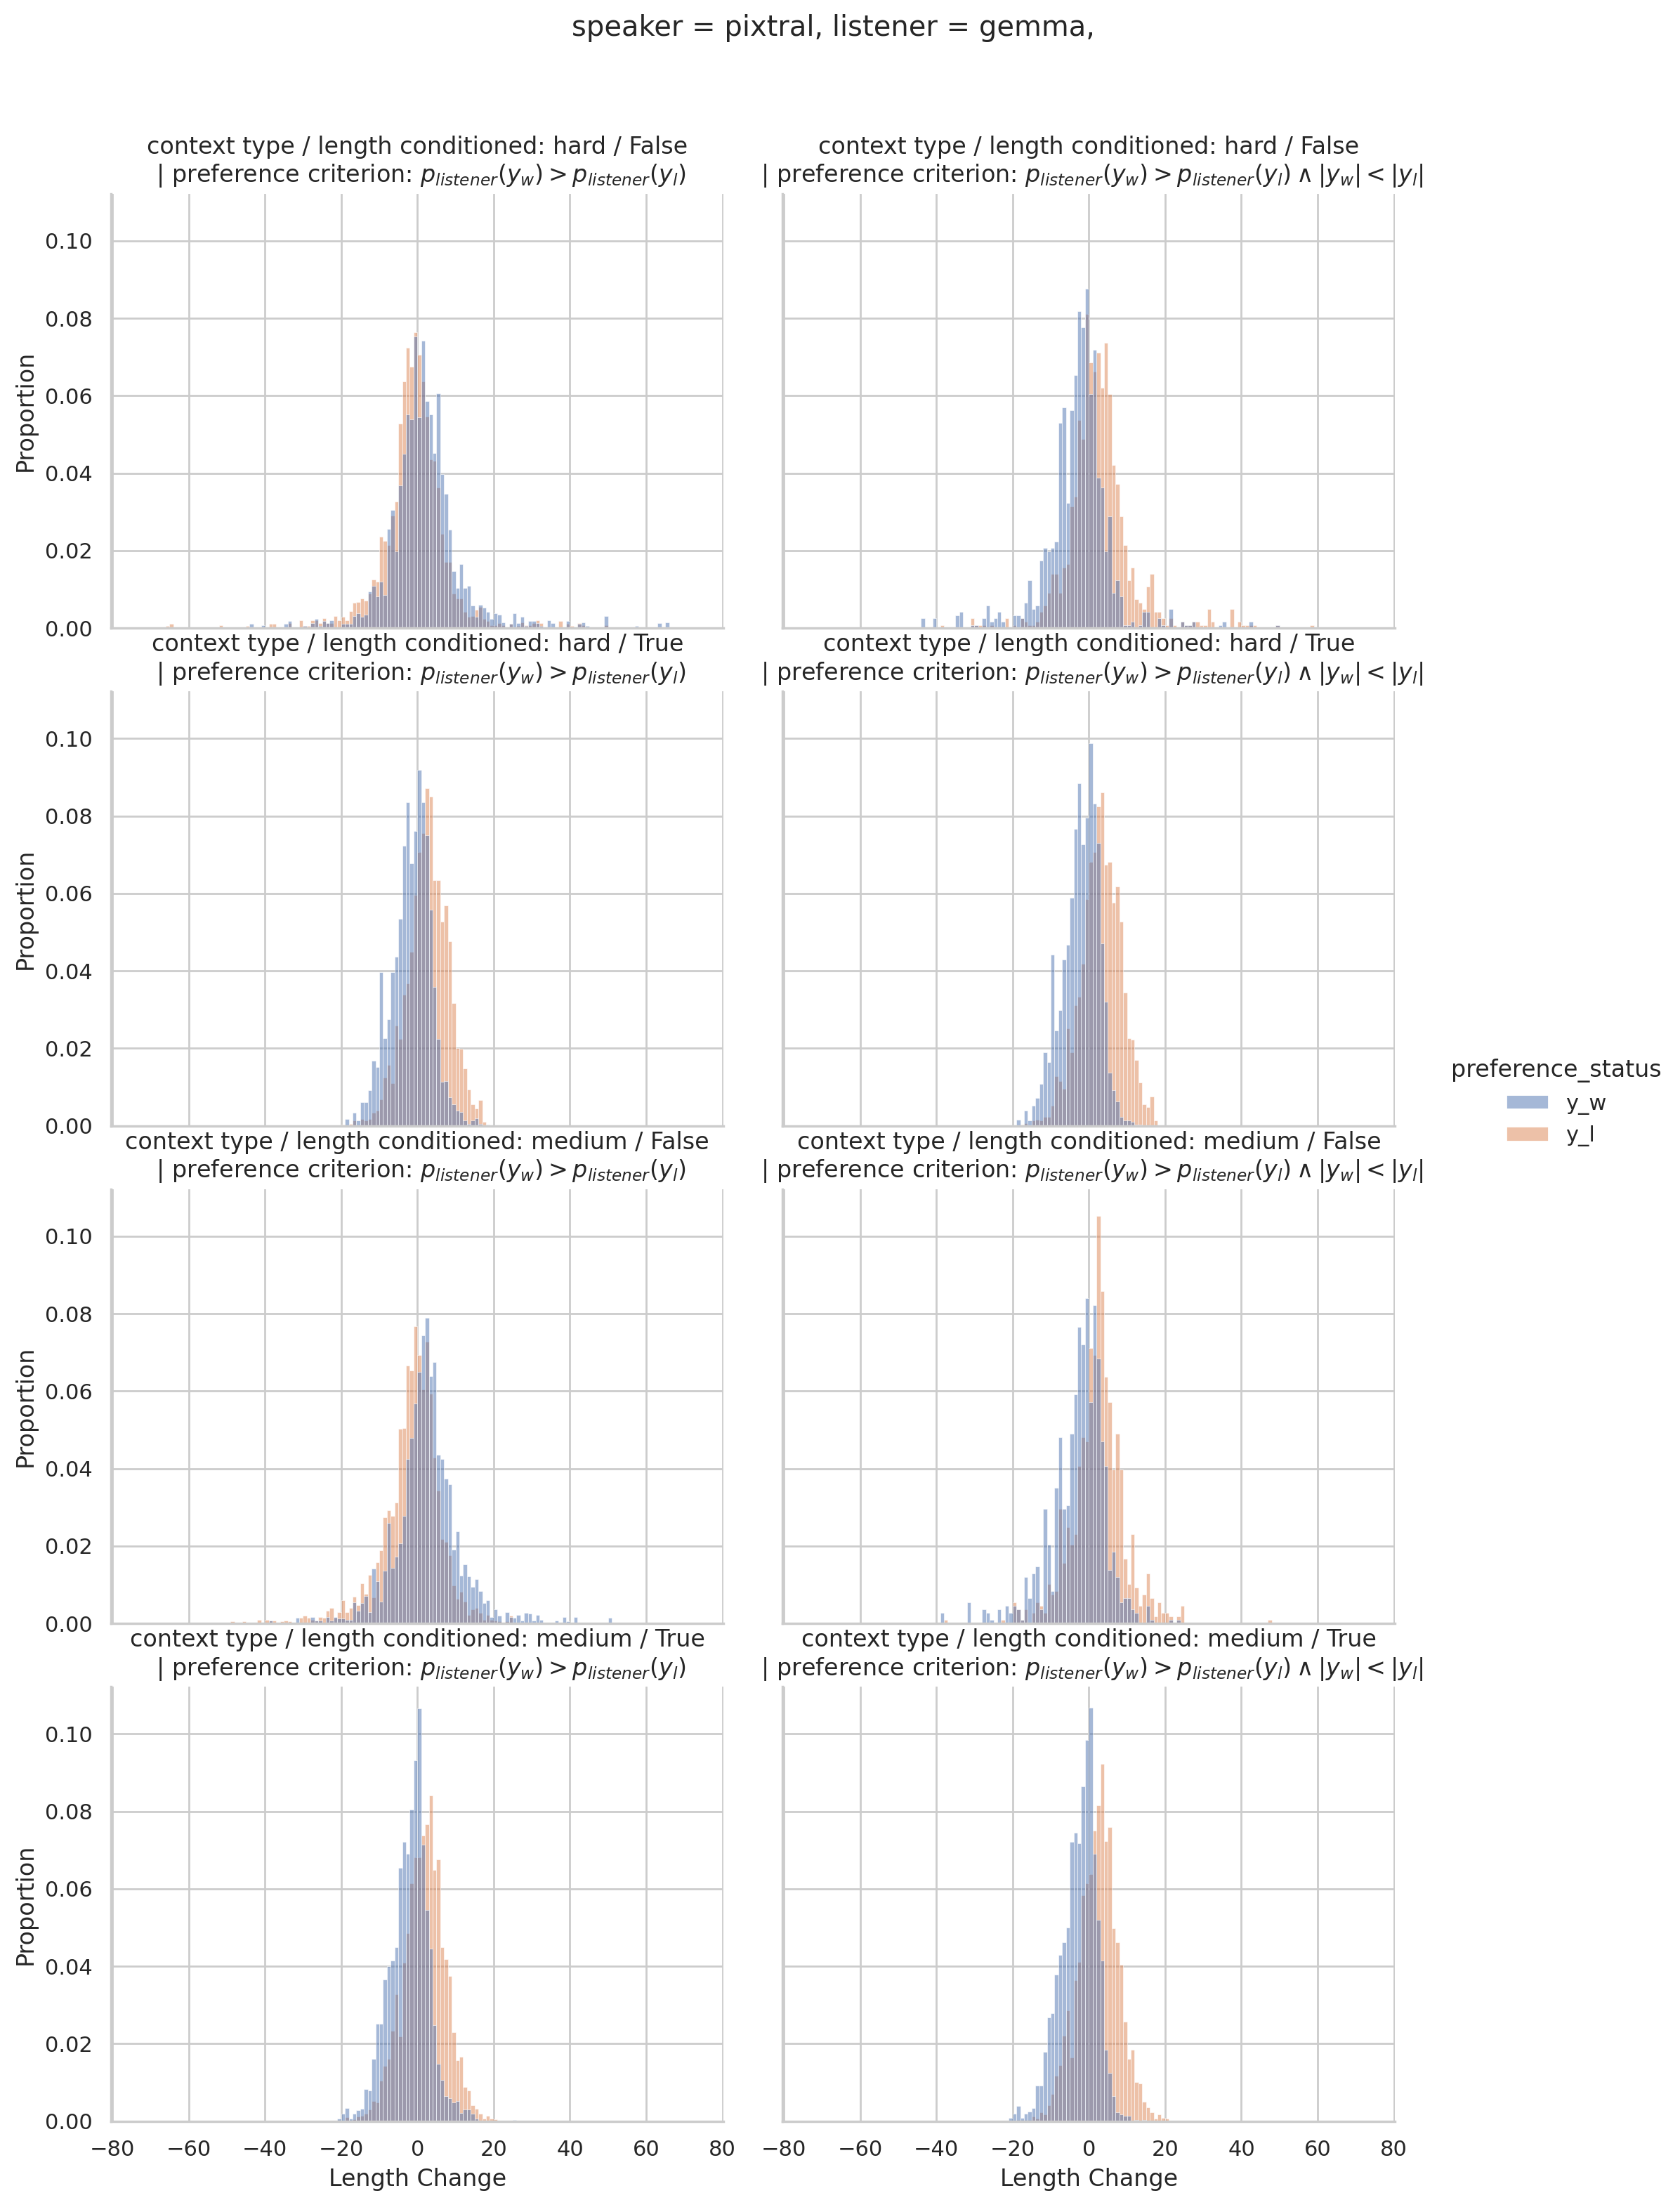

In [93]:
g = sns.displot(
    data=long_df,
    x="len_change",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("Length Change", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

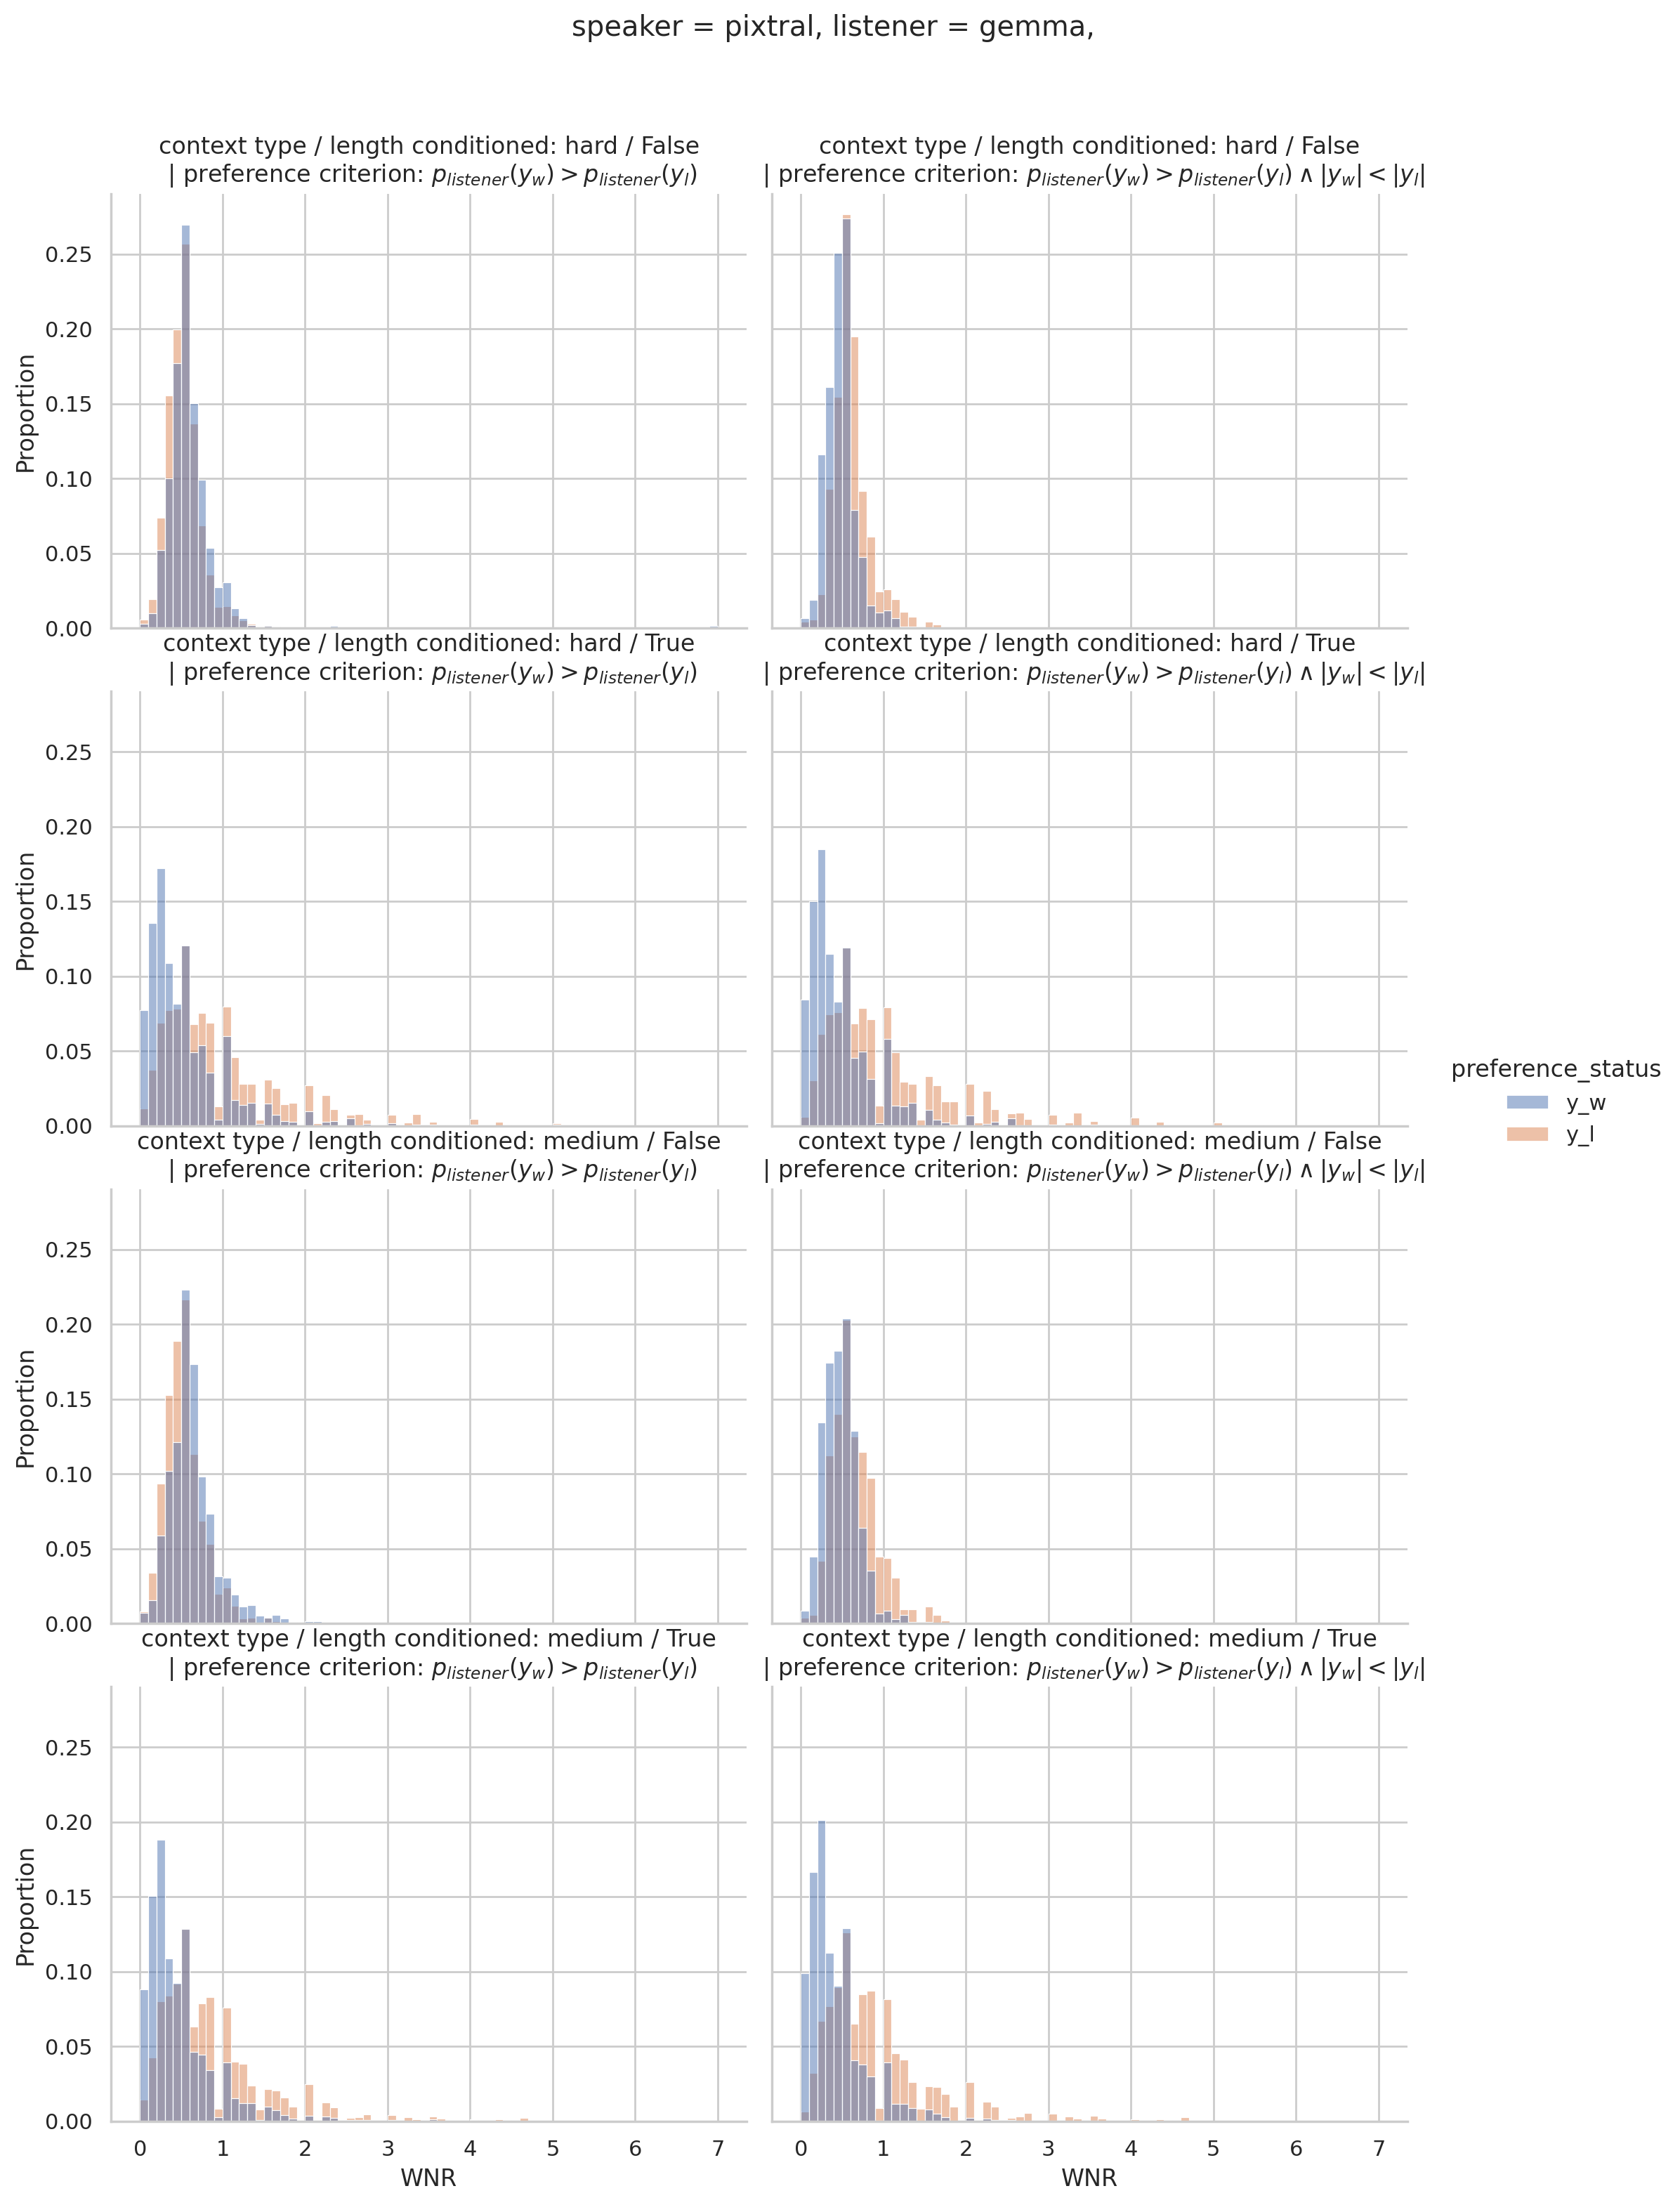

In [95]:
g = sns.displot(
    data=long_df,
    x="last_wnr",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=0.1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("WNR", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

In [97]:
SPEAKER_MODEL = "pixtral"
LISTENER_MODEL = "pixtral"
long_df = get_model_pair_results(df, SPEAKER_MODEL, LISTENER_MODEL).replace({
    "context_type": {
        "coco_medium": "medium",
        "coco_hard": "hard",
    },
    "preference_criterion": {
        "target_prob_only": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l)$",
        "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",
    },
})
long_df["context type / length conditioned"] = long_df.apply(
    lambda x: (
        f"{x['context_type']} / {x['length_conditioned']}"
    ),
    axis=1,
)

<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1930062/798754460.py:10: SyntaxWarning: invalid escape sequence '\w'
  "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",


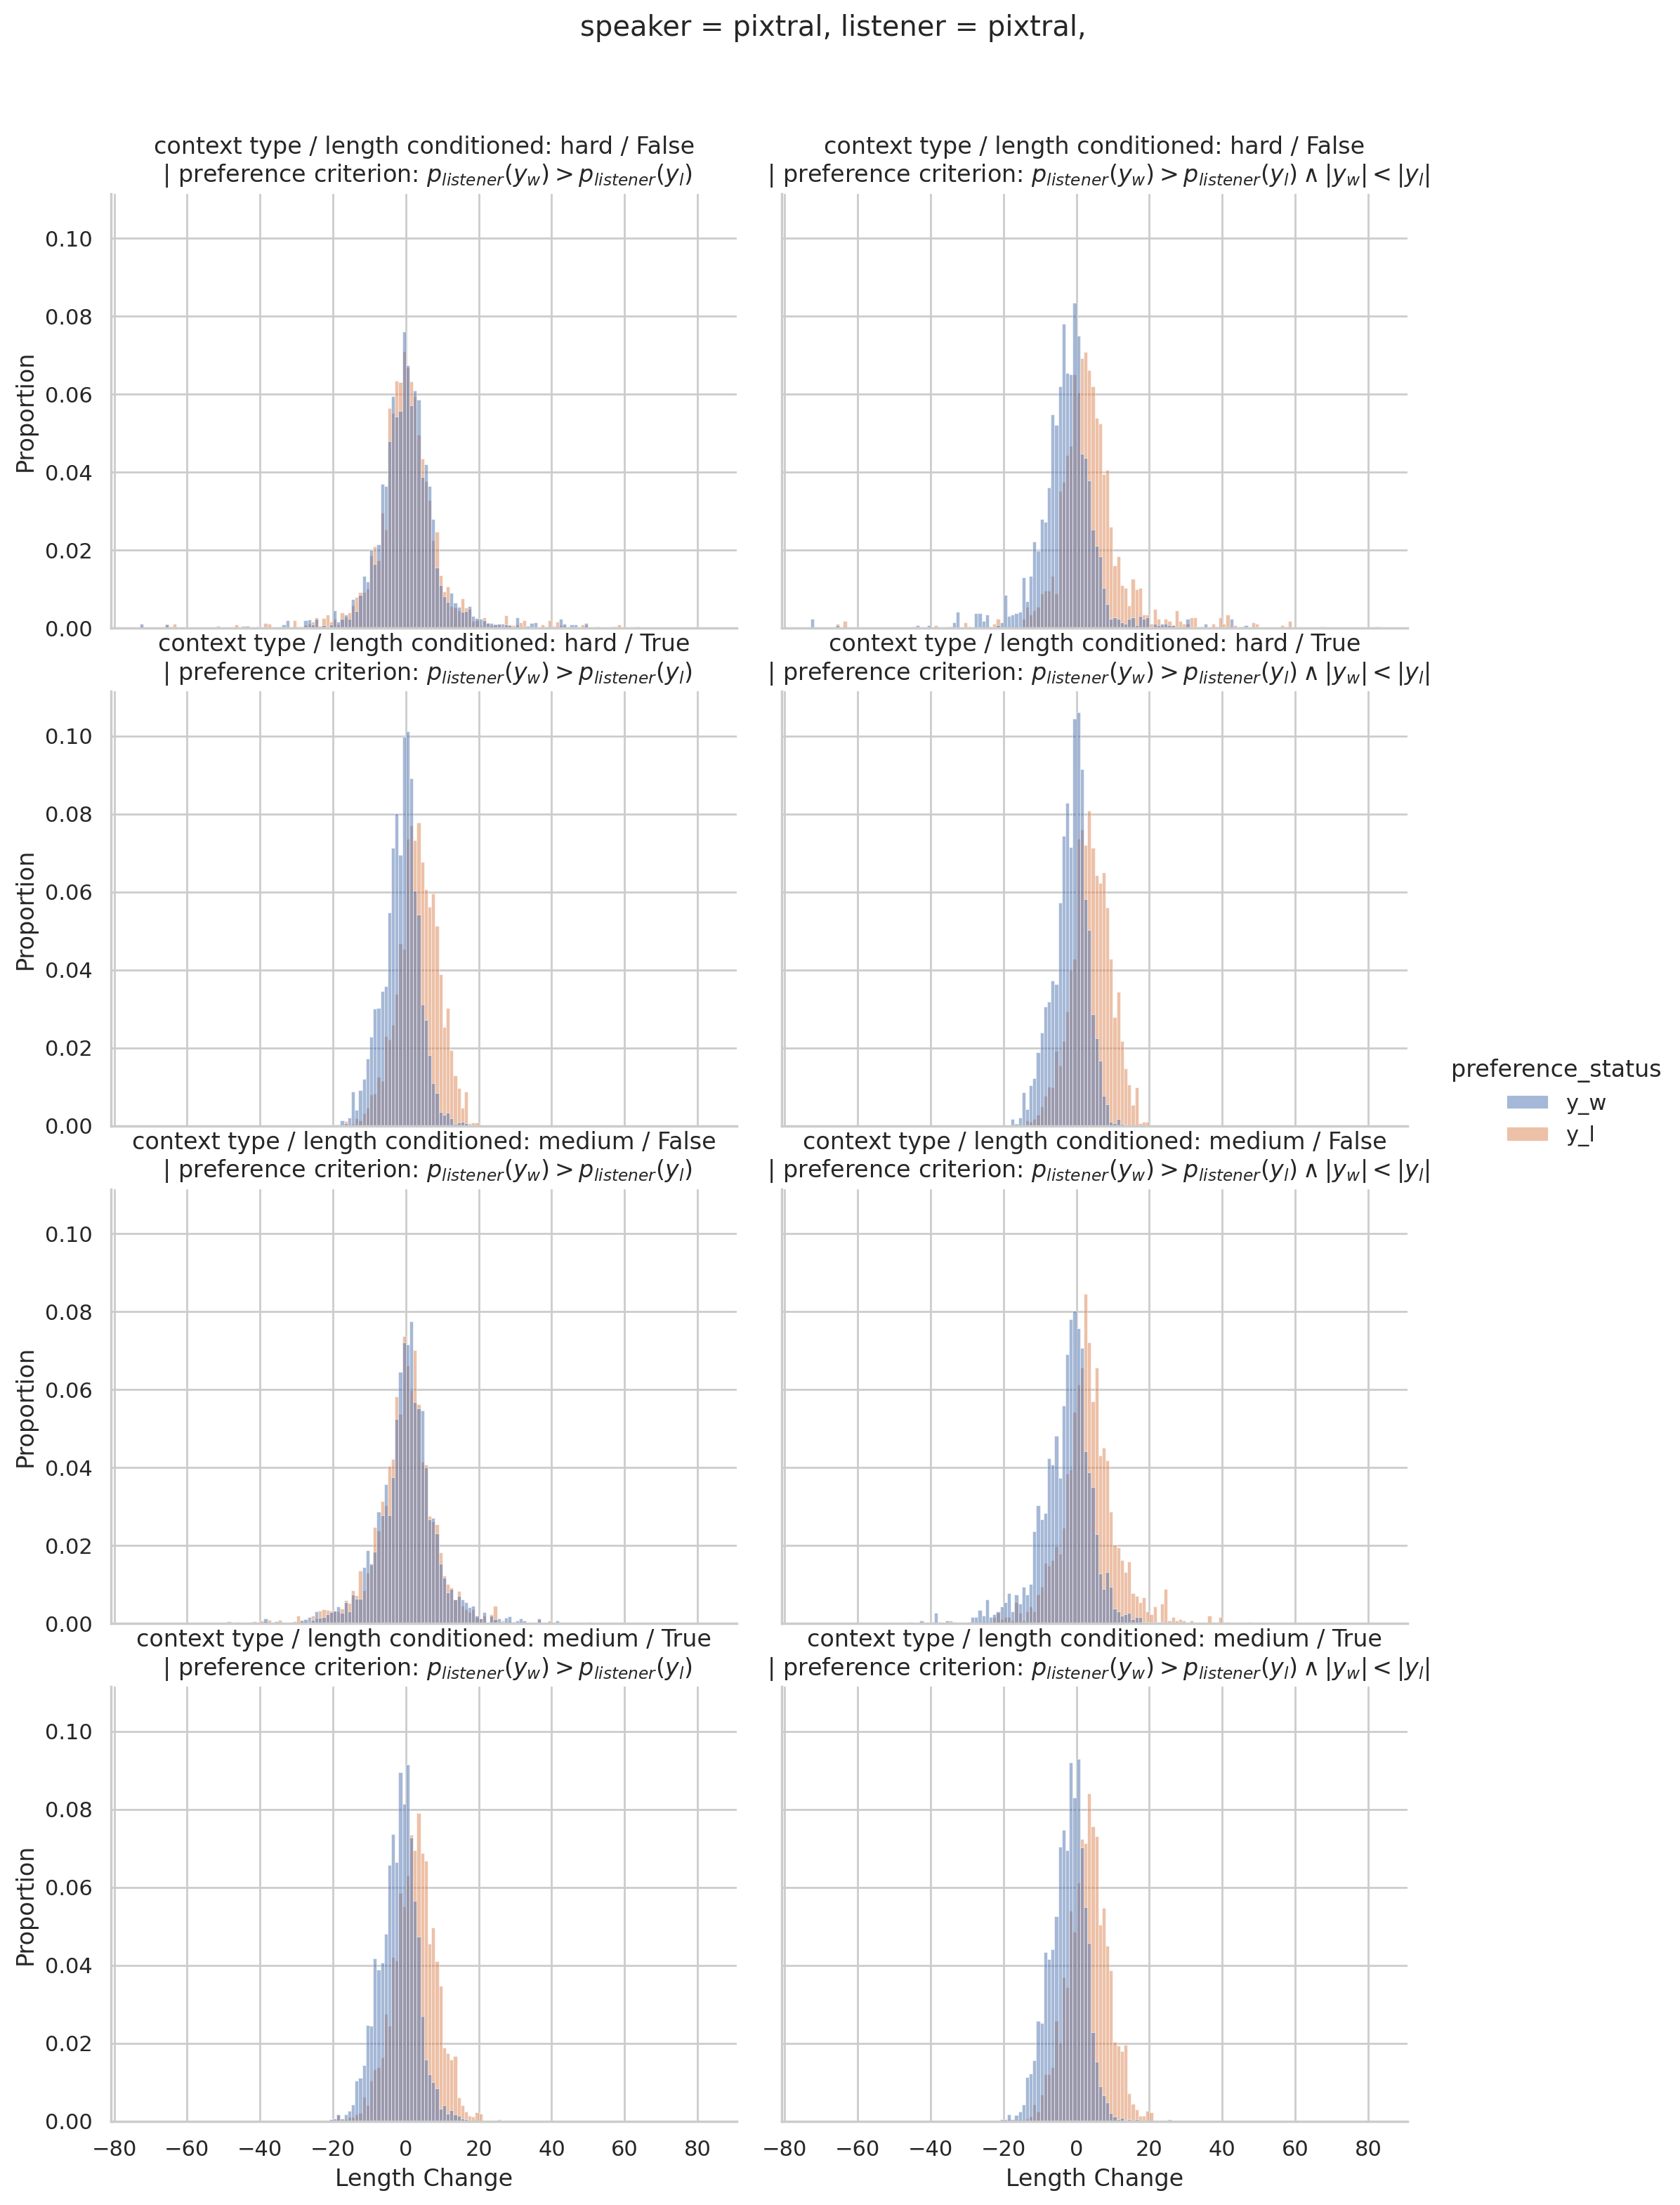

In [98]:
g = sns.displot(
    data=long_df,
    x="len_change",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("Length Change", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

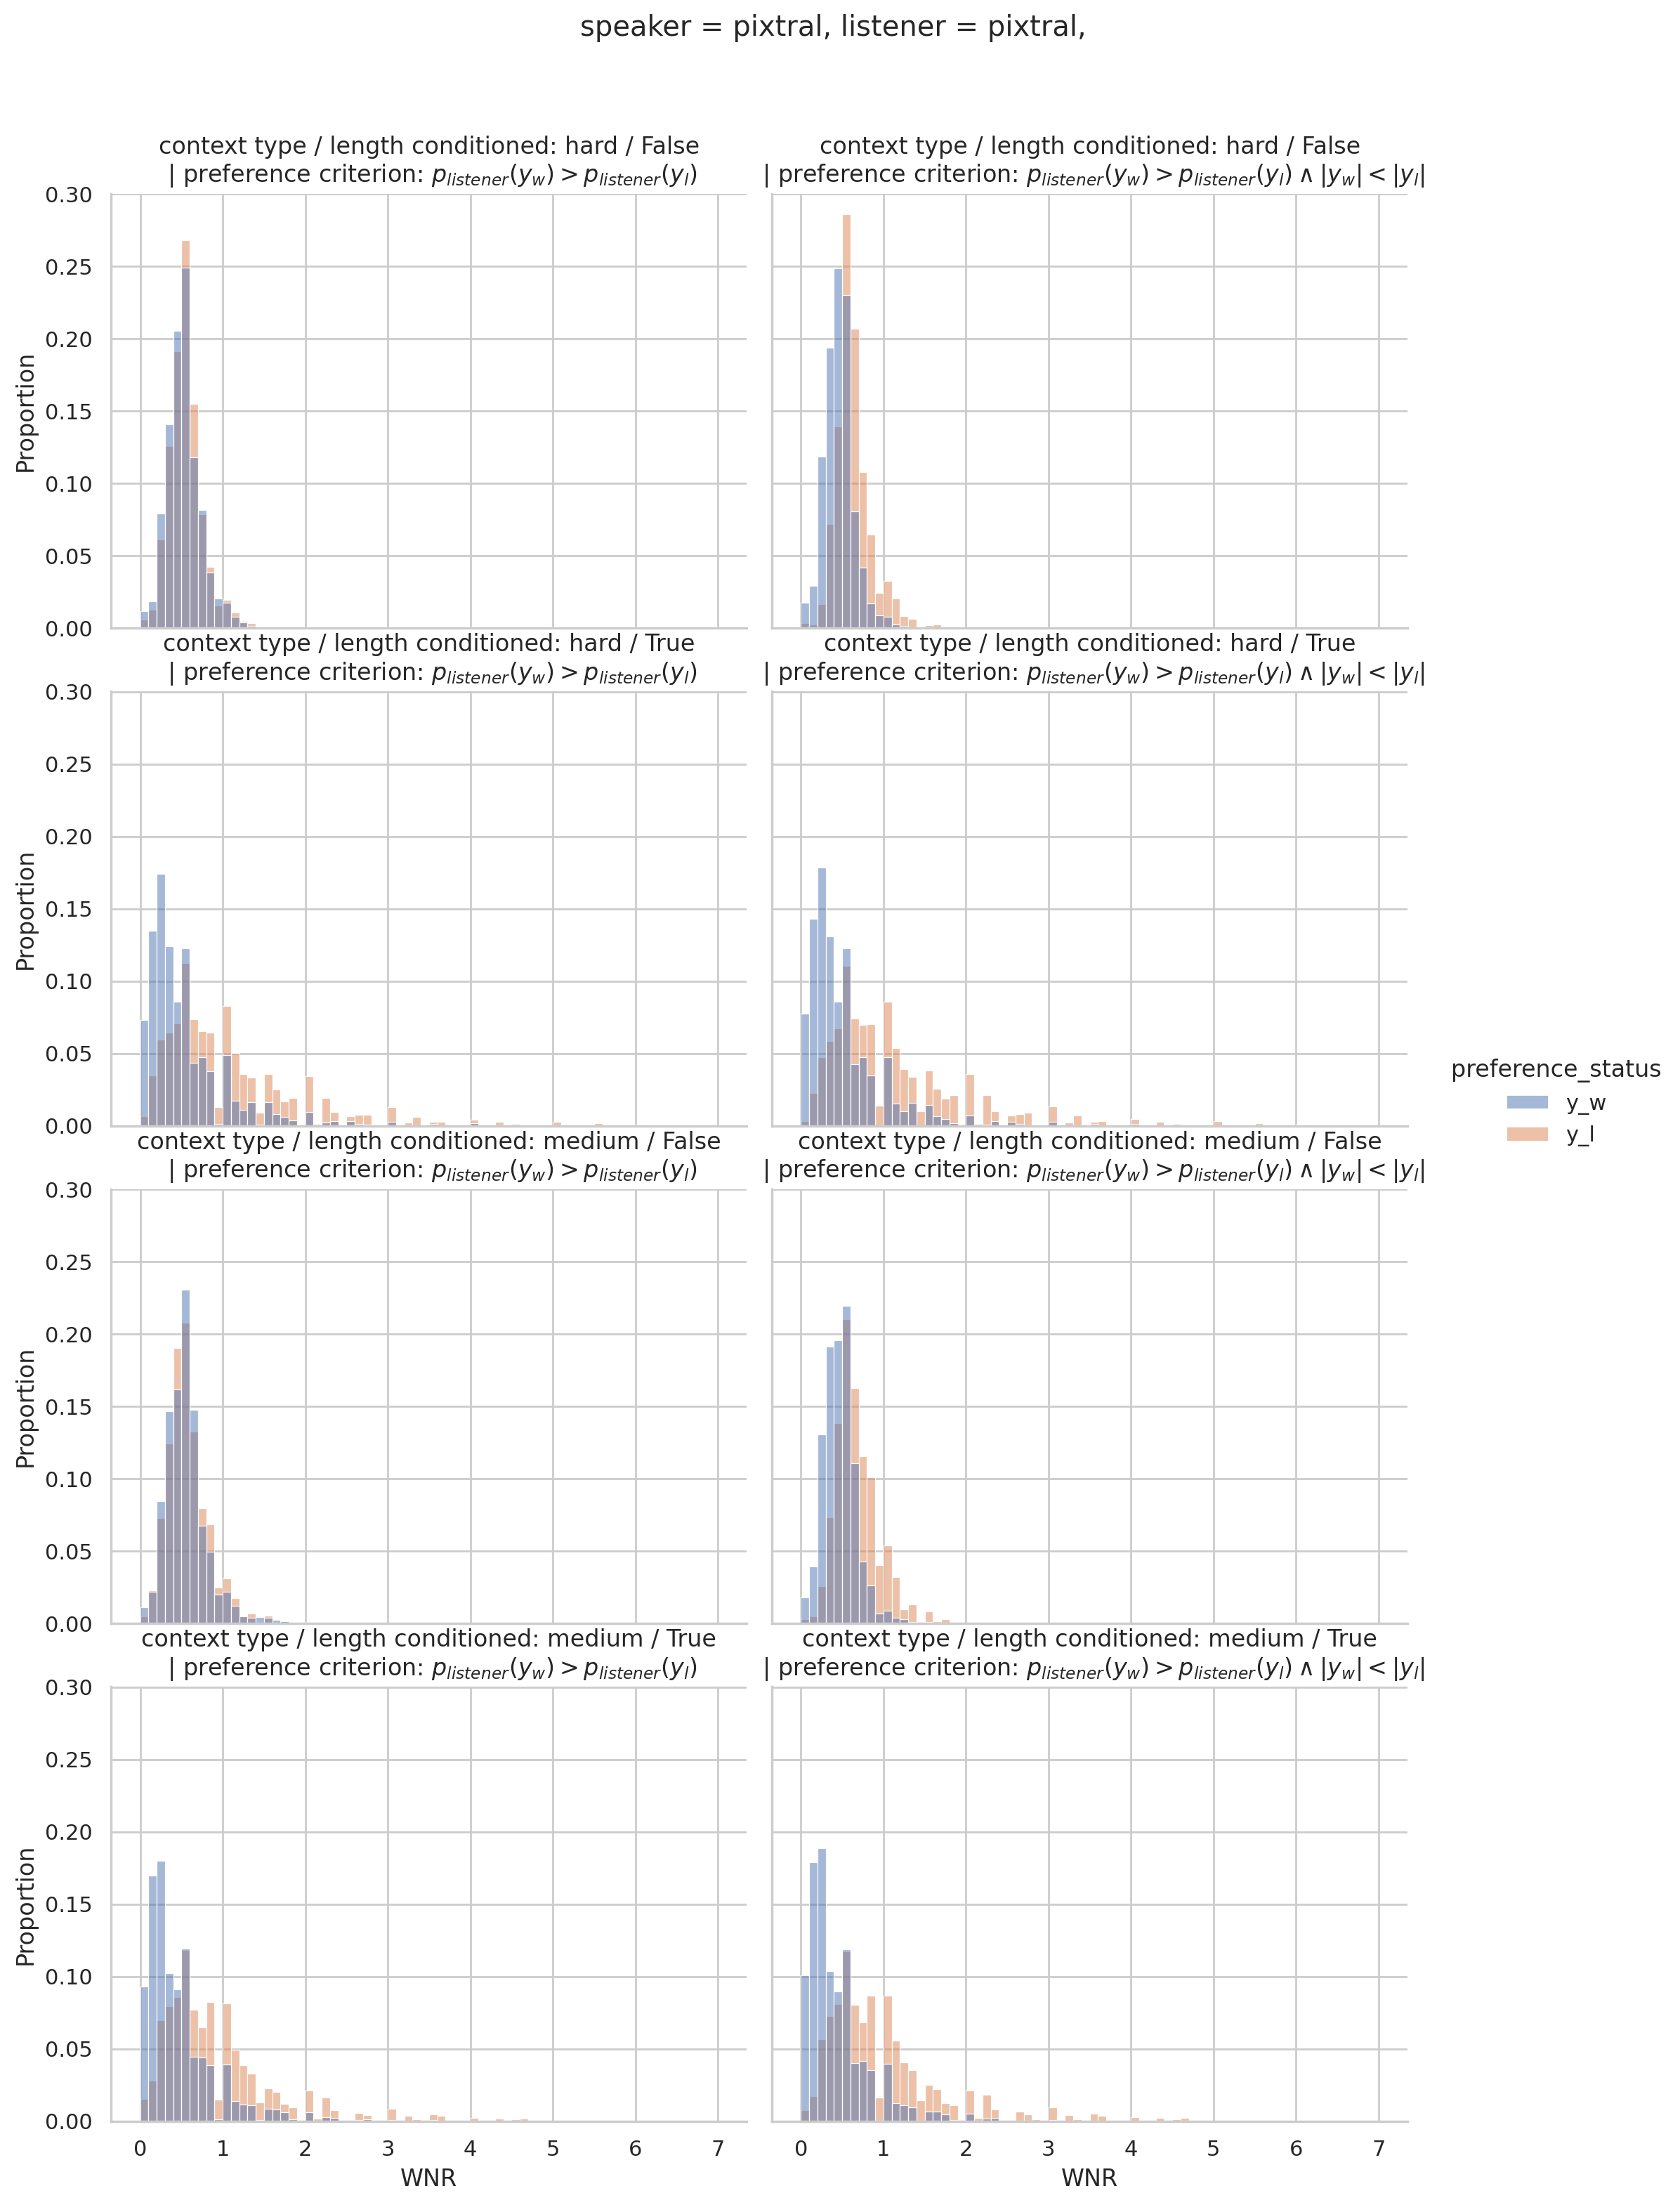

In [99]:
g = sns.displot(
    data=long_df,
    x="last_wnr",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=0.1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("WNR", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

In [100]:
SPEAKER_MODEL = "gemma"
LISTENER_MODEL = "pixtral"
long_df = get_model_pair_results(df, SPEAKER_MODEL, LISTENER_MODEL).replace({
    "context_type": {
        "coco_medium": "medium",
        "coco_hard": "hard",
    },
    "preference_criterion": {
        "target_prob_only": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l)$",
        "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",
    },
})
long_df["context type / length conditioned"] = long_df.apply(
    lambda x: (
        f"{x['context_type']} / {x['length_conditioned']}"
    ),
    axis=1,
)

<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1930062/1238156690.py:10: SyntaxWarning: invalid escape sequence '\w'
  "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",


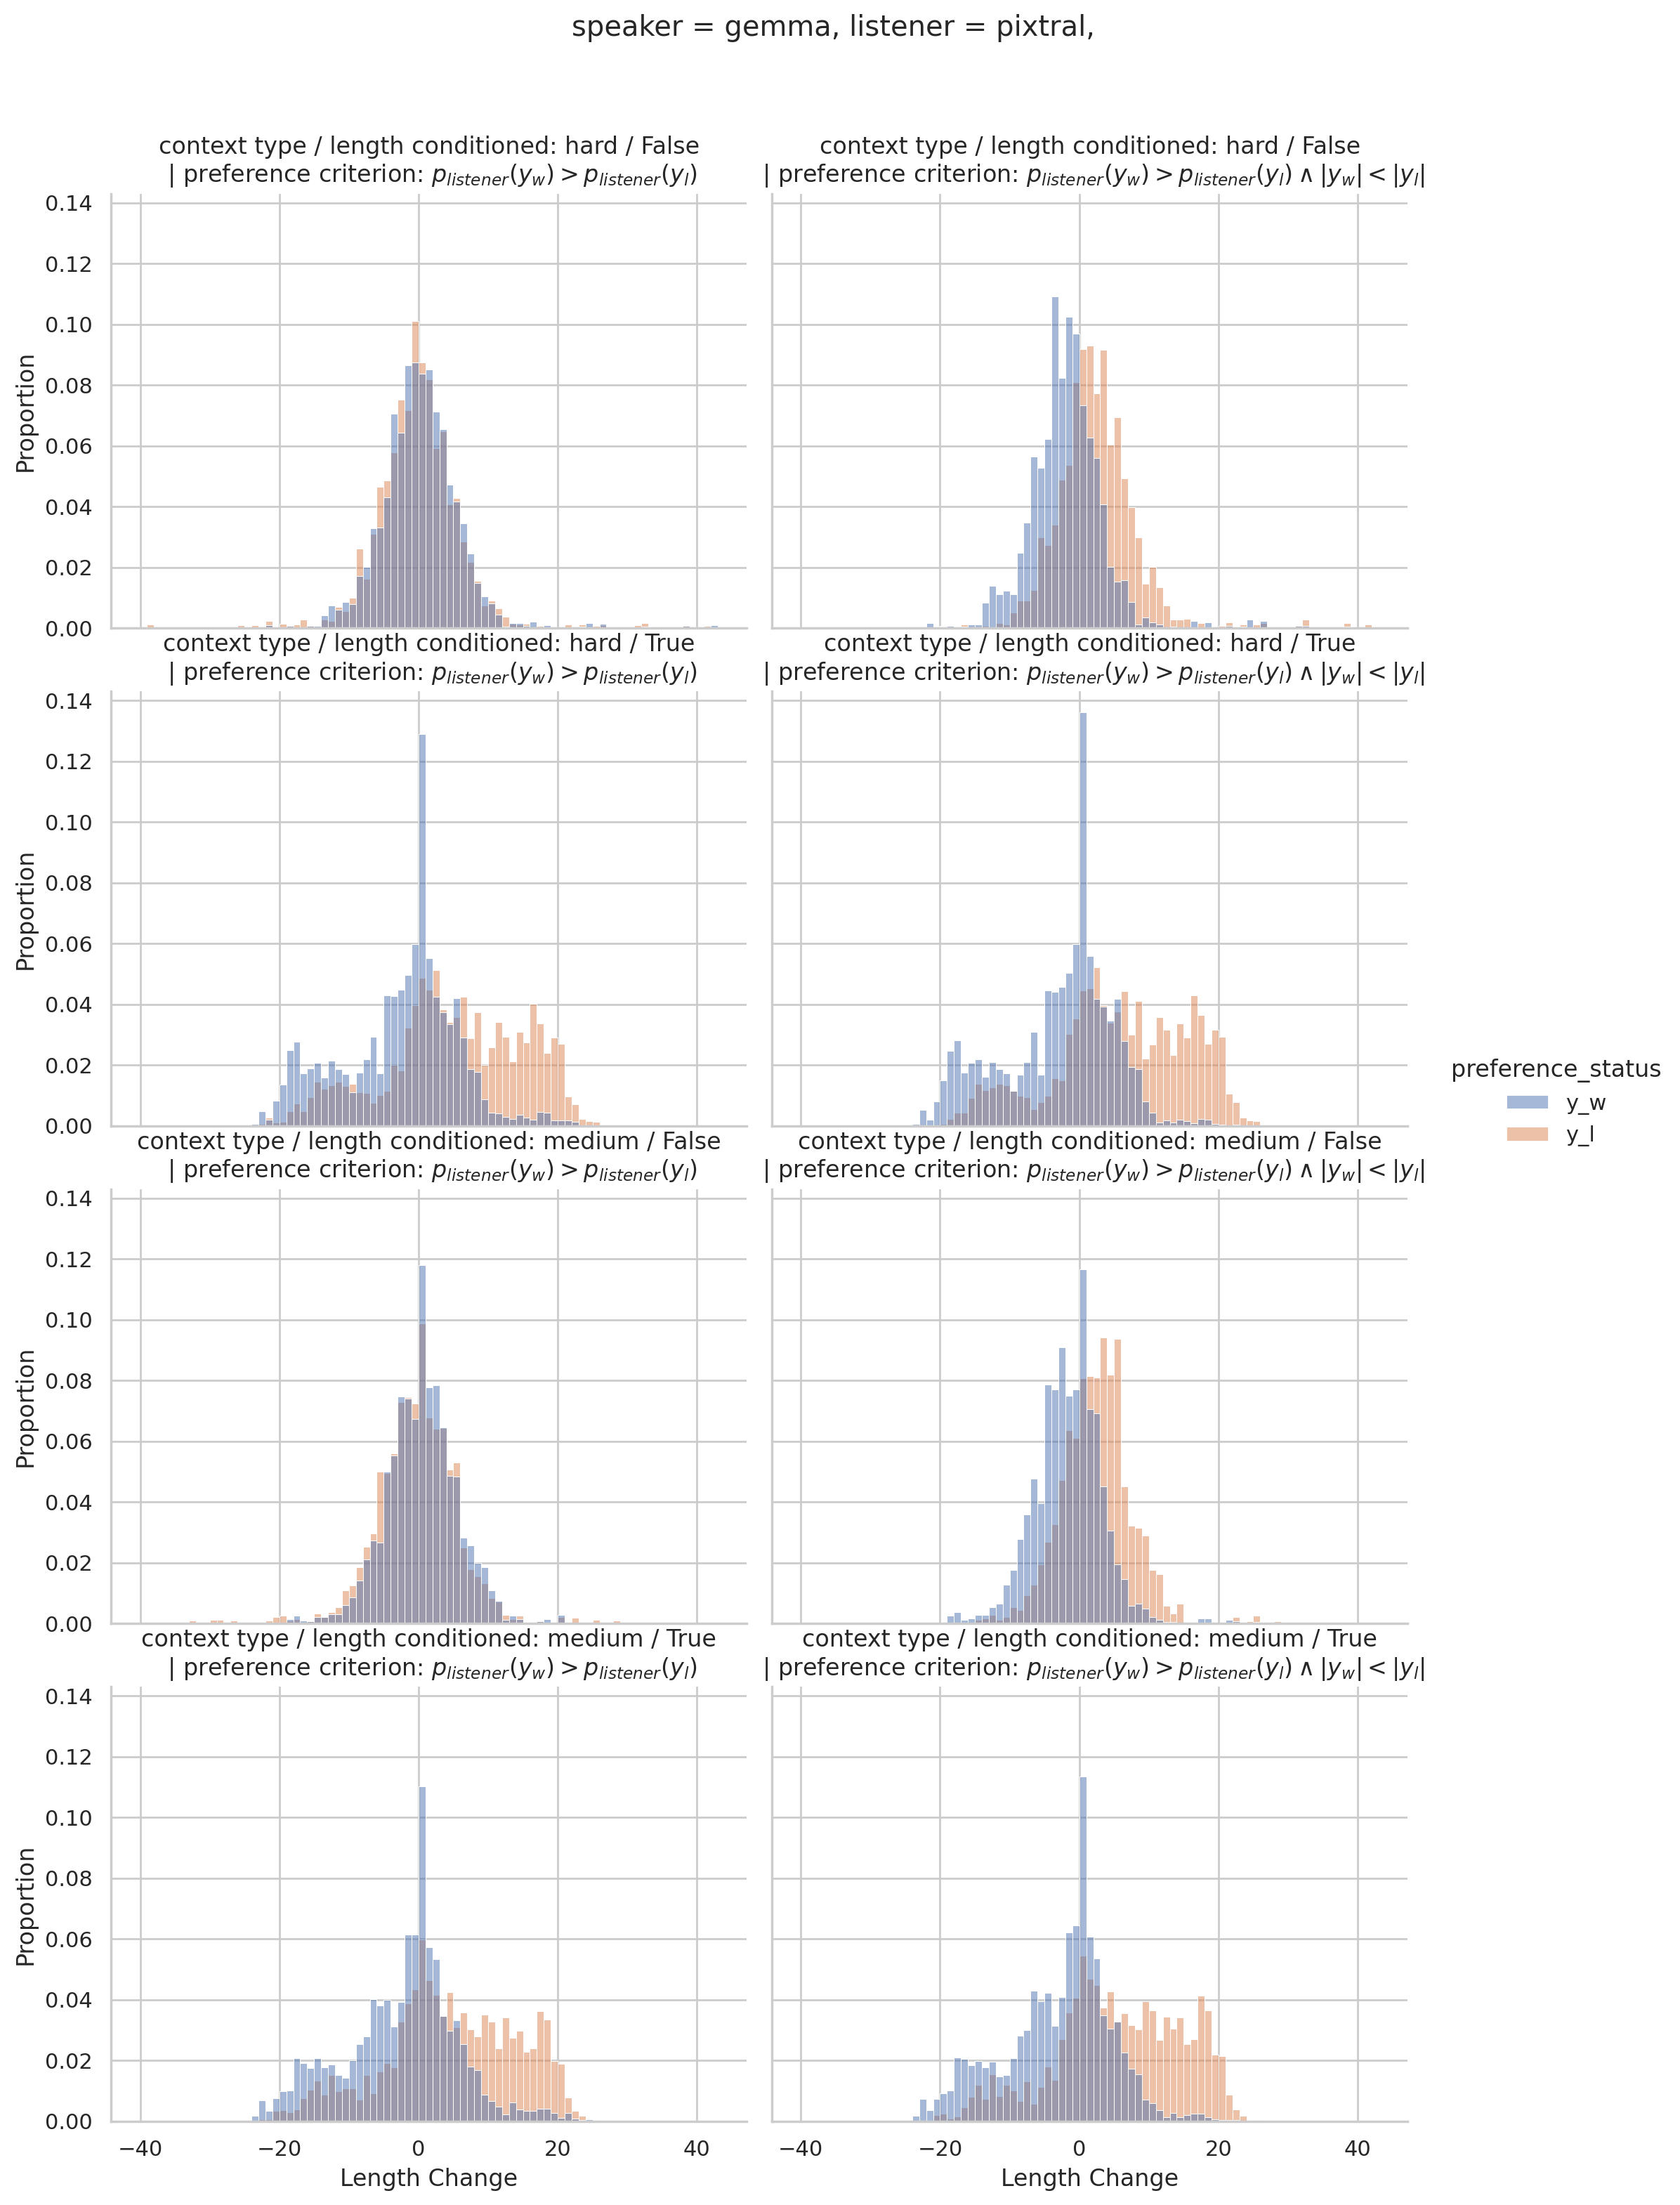

In [101]:
g = sns.displot(
    data=long_df,
    x="len_change",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("Length Change", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

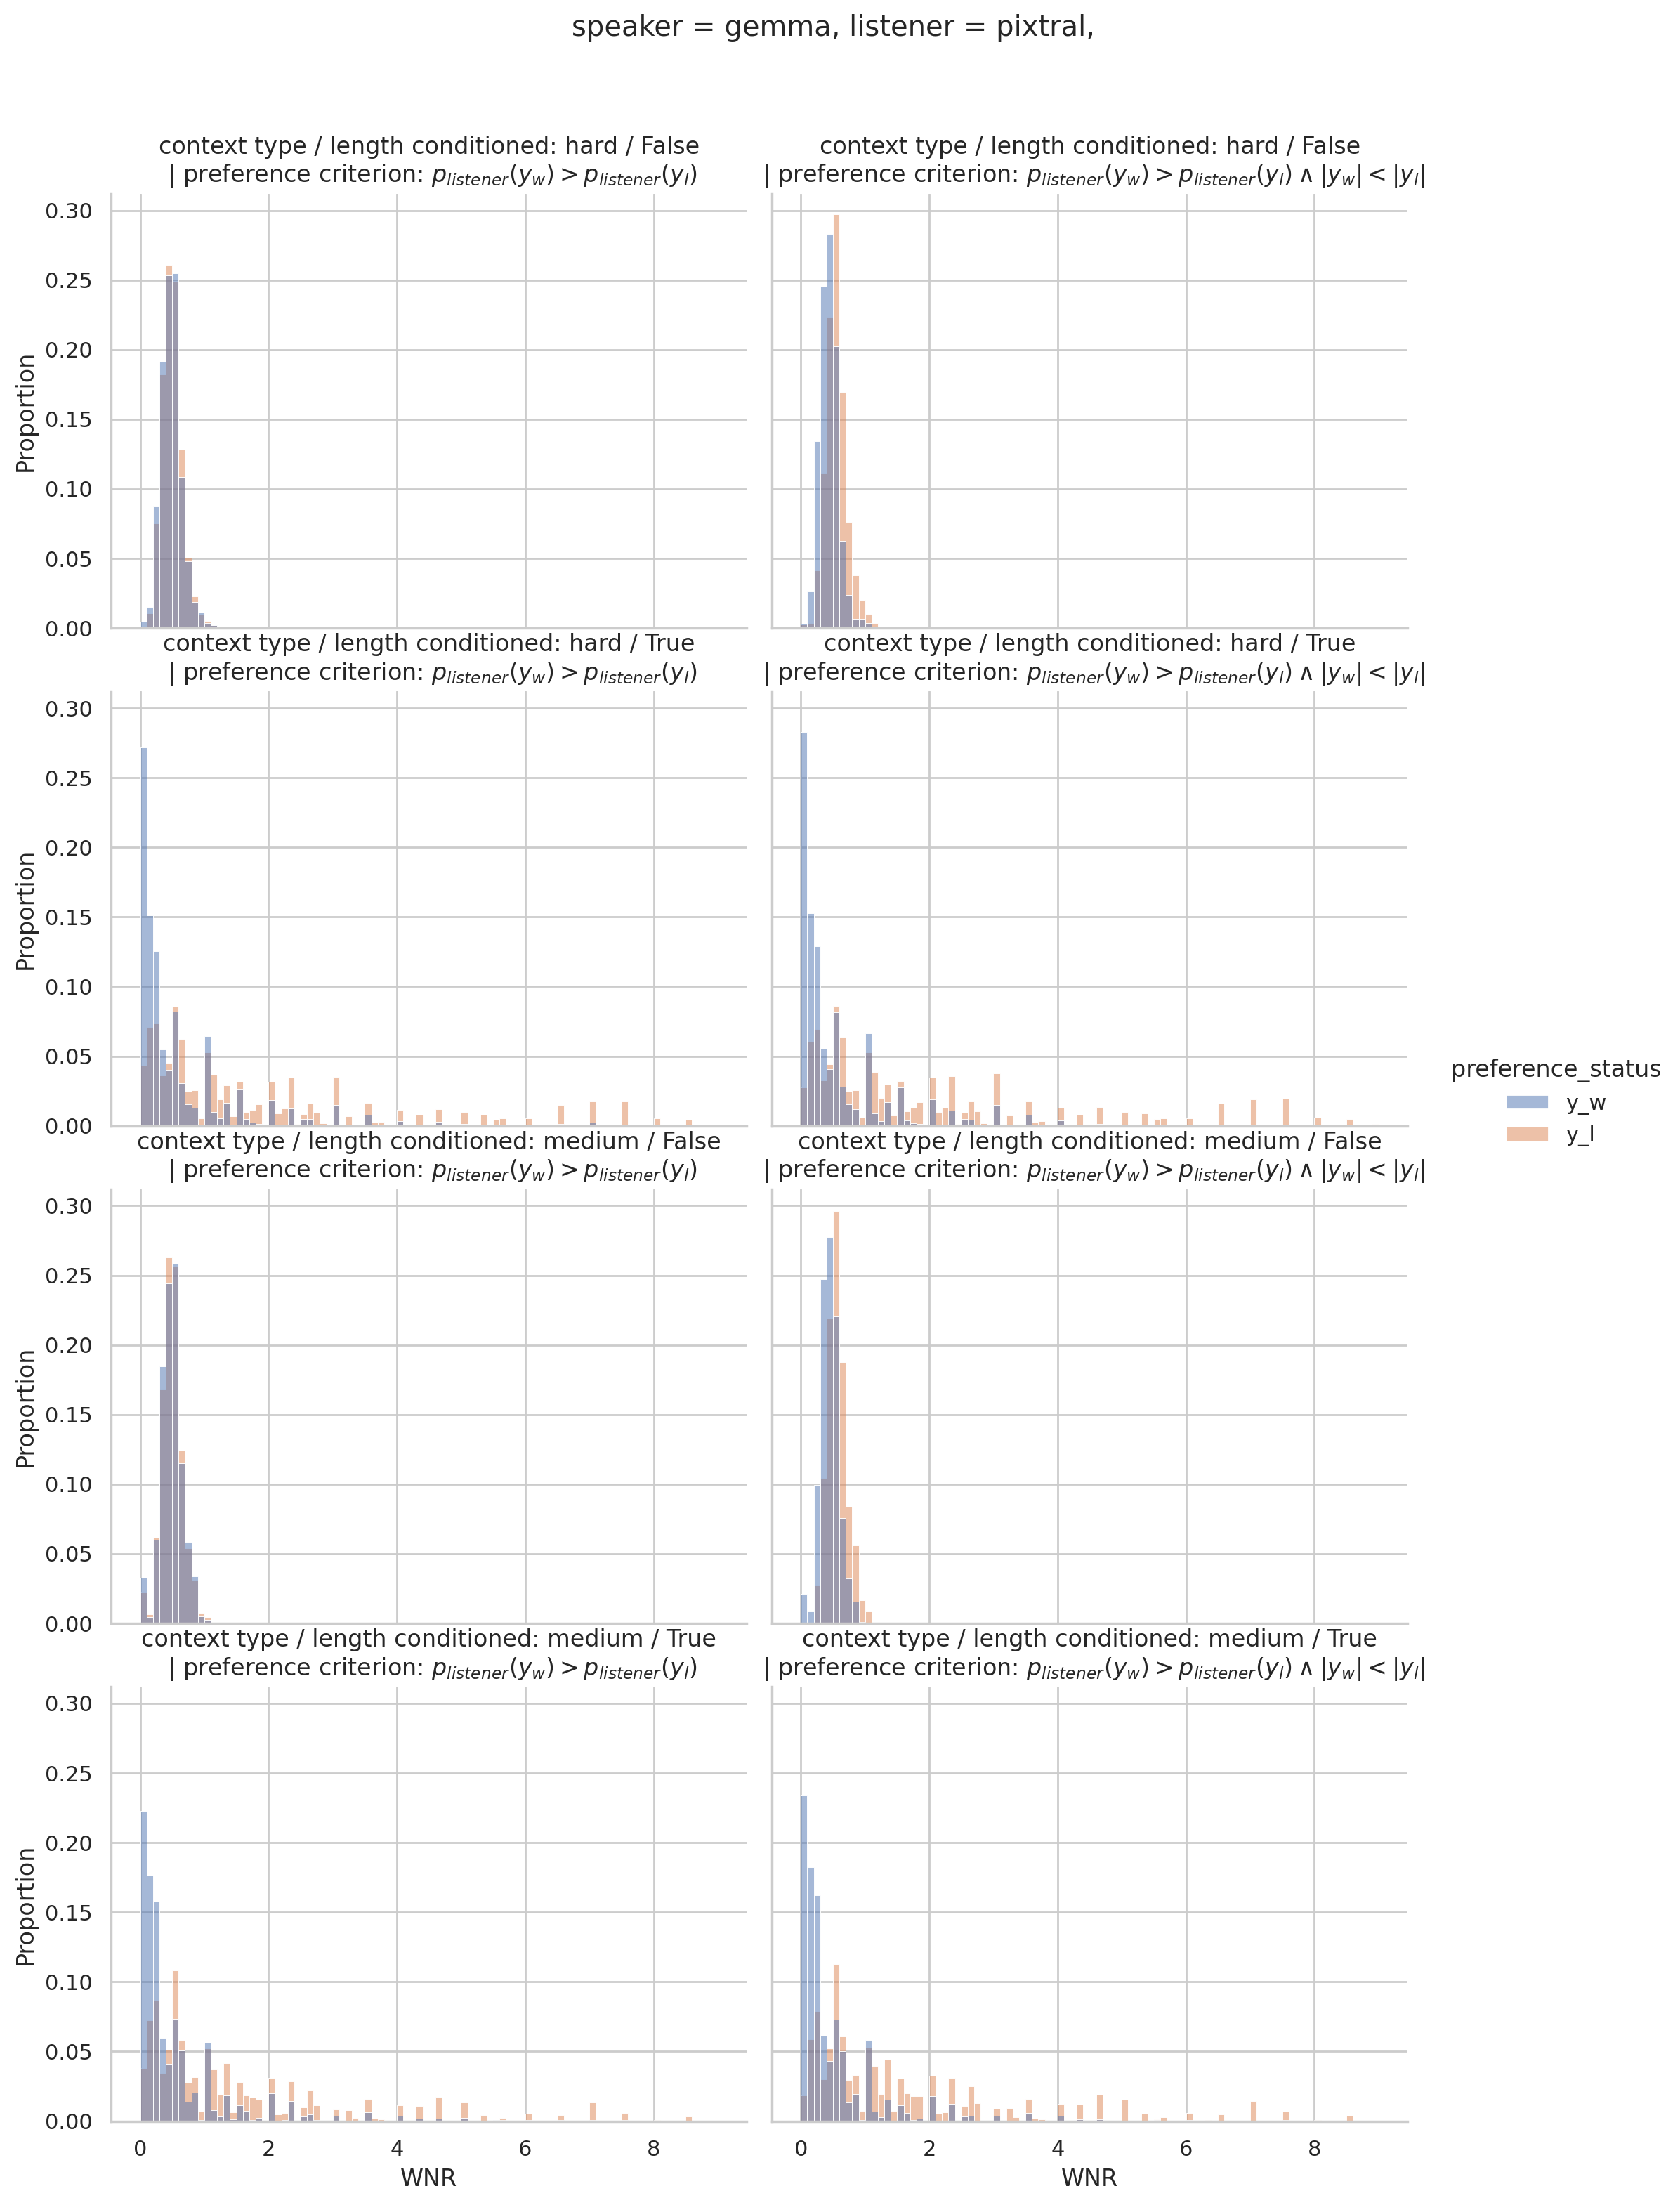

In [102]:
g = sns.displot(
    data=long_df,
    x="last_wnr",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=0.1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("WNR", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

In [103]:
SPEAKER_MODEL = "gemma"
LISTENER_MODEL = "gemma"
long_df = get_model_pair_results(df, SPEAKER_MODEL, LISTENER_MODEL).replace({
    "context_type": {
        "coco_medium": "medium",
        "coco_hard": "hard",
    },
    "preference_criterion": {
        "target_prob_only": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l)$",
        "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",
    },
})
long_df["context type / length conditioned"] = long_df.apply(
    lambda x: (
        f"{x['context_type']} / {x['length_conditioned']}"
    ),
    axis=1,
)

<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1930062/2936244429.py:10: SyntaxWarning: invalid escape sequence '\w'
  "target_prob_and_length": f"$p_{{listener}}(y_w) > p_{{listener}}(y_l) \wedge |y_w| < |y_l|$",


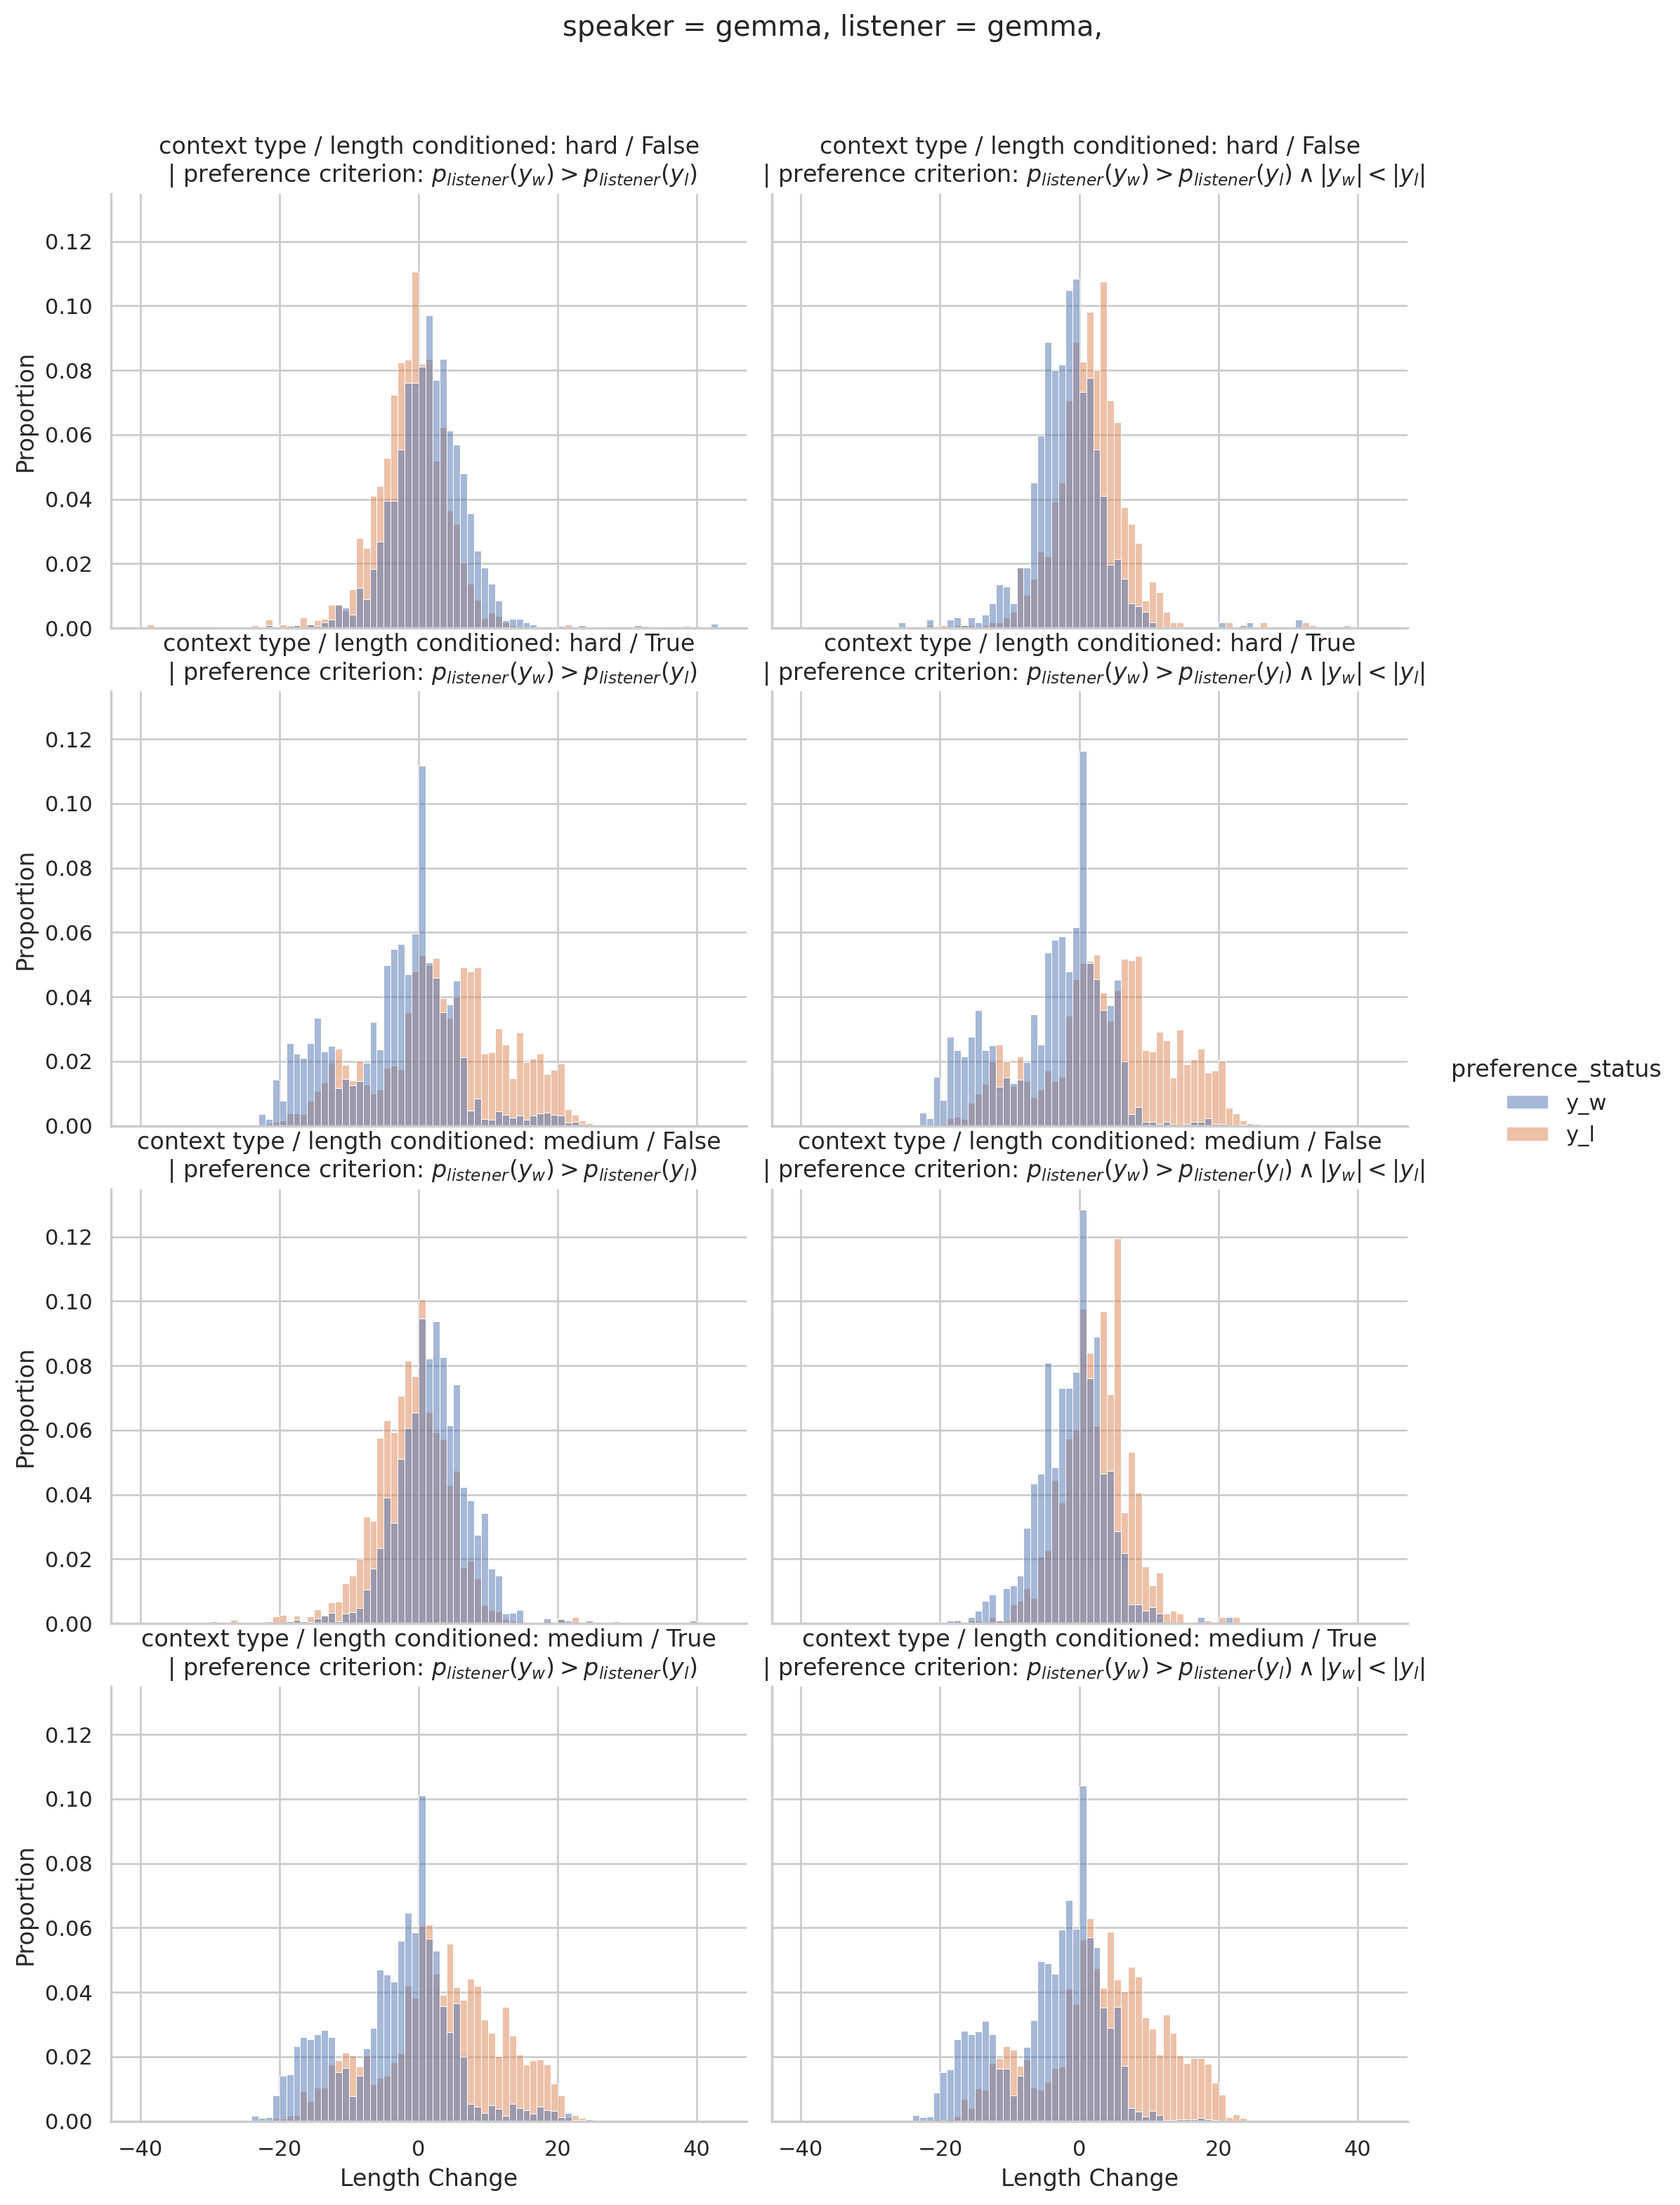

In [104]:
g = sns.displot(
    data=long_df,
    x="len_change",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("Length Change", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)

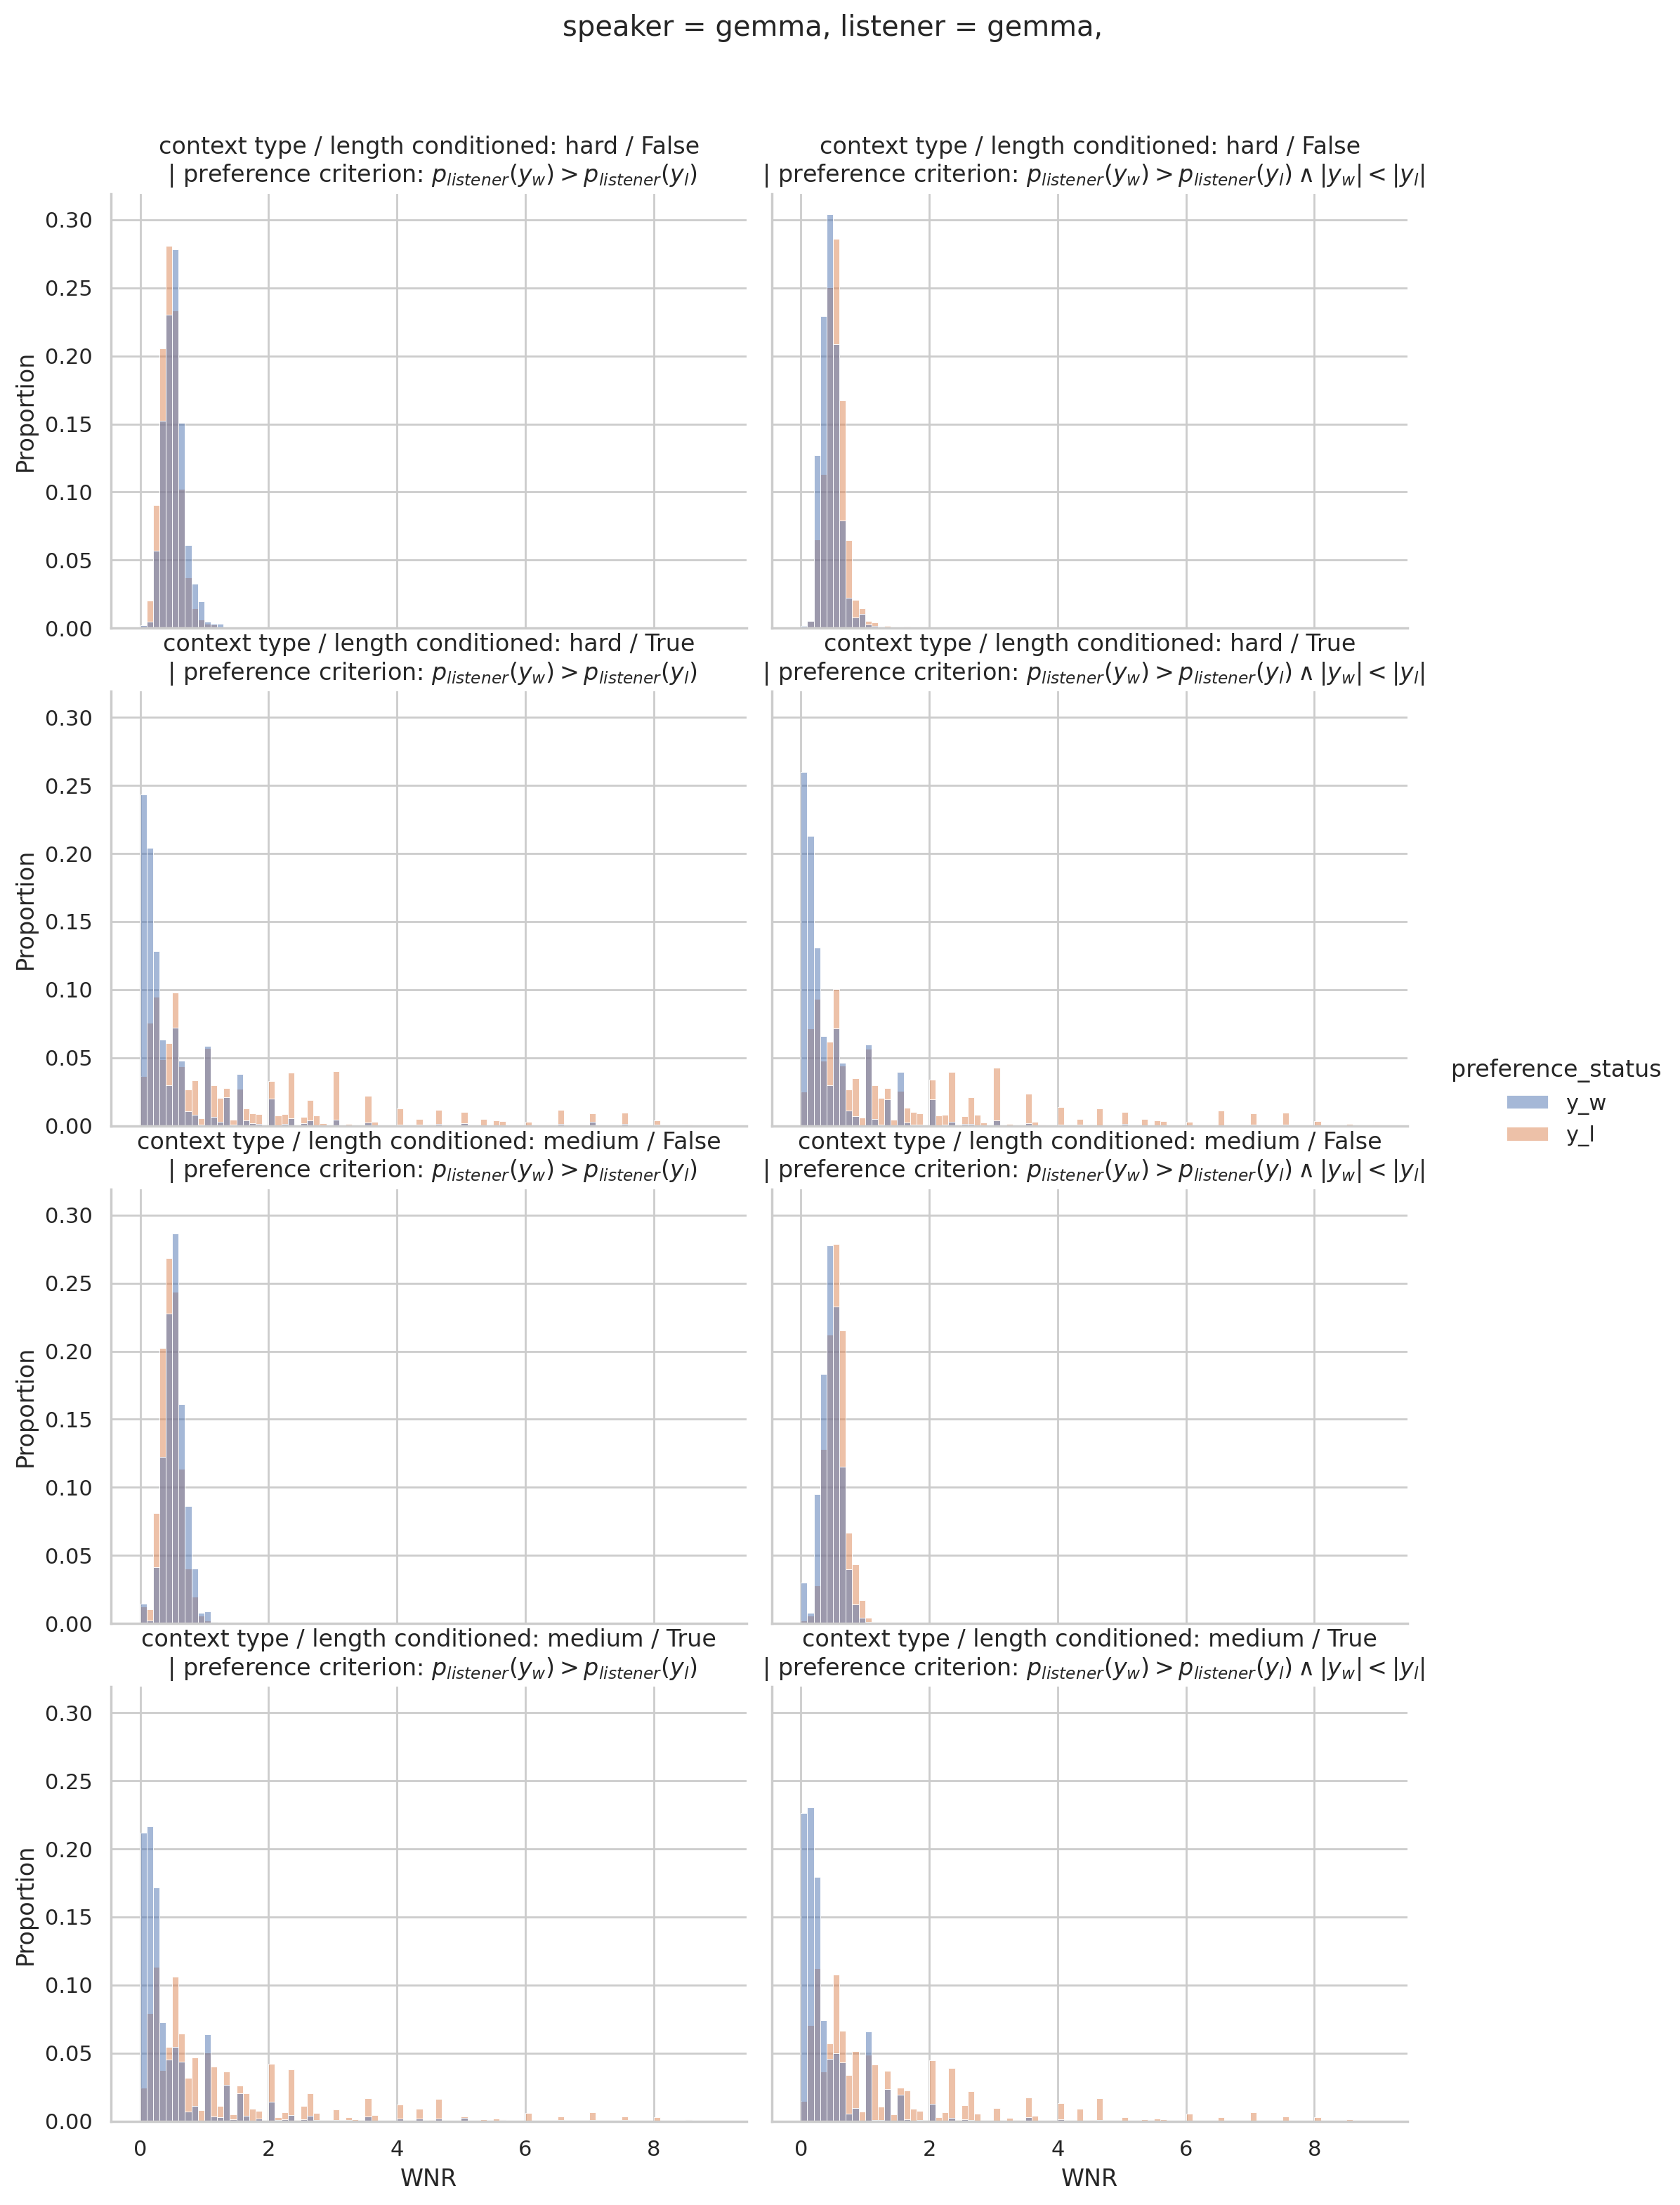

In [105]:
g = sns.displot(
    data=long_df,
    x="last_wnr",
    hue="preference_status",
    col="preference_criterion",
    row="context type / length conditioned",
    stat="proportion",
    binwidth=0.1,
    multiple="layer",  # overlays the histograms
    alpha=0.5,
    height=4,
    aspect=1.3,
    common_norm=False,
)

# 3. tweak labels/title
g.set_axis_labels("WNR", "Proportion")
g.figure.suptitle(
    f"speaker = {SPEAKER_MODEL}, listener = {LISTENER_MODEL},\n"
)
g.set_titles(
    col_template="preference criterion: {col_name}",
    row_template="context type / length conditioned: {row_name}\n"
)
g.figure.subplots_adjust(top=0.9)